In [1]:
import os
if not os.path.exists('../sample'):
    print('No Sample Found')
    quit()
else:
    docs = os.listdir(os.path.join(os.getcwd(), '..', 'sample'))
    docs = [f for f in docs if f.endswith('.txt')]
    print(f'Found {len(docs)} Samples')

Found 859 Samples


In [2]:
import re
rule1_keywords = r"(?:^|,)\s*现将|(?:^|,)\s*现就|现.*?如下|(?:^|,)\s*为[^,]*?落实|(?:^|,)\s*为[^,]*?贯彻|(?:^|,)\s*为规范|(?:^|,)\s*为了规范|(?:^|,)\s*现提出|(?:^|,)\s*提出如下|(?:^|,)\s*提出以下"
rule1_regex = re.compile(rule1_keywords)
def rule1(text):
    lines = text.split('\n')
    matches = []
    for line in lines:
        if len(line.strip()) > 0:
            sentences = line.split('。')
            for sentence in sentences:
                sentenceMatch = rule1_regex.search(sentence)
                if sentenceMatch is not None:
                    matches.append((sentence.strip(), sentenceMatch.group().strip()))
    return matches

In [3]:
# test rule 1 on a random sample
import random
doc = ''
idx = random.randrange(0, len(docs))
print(f'Select {idx}-th doc {docs[idx]}.')
with open(os.path.join(os.getcwd(), '..', 'sample', docs[idx]), 'r', encoding='utf-8') as f:
    doc = f.read()
    print(rule1(doc))

Select 785-th doc 徐州市民政局关于印发《徐州市军休机构服务管...(FBM-CLI.12.3863945).txt.
[('为进一步做好军队离退休干部服务管理工作，切实加强军休服务管理机构建设，确保军休干部各项待遇准确落实，根据中共中央办公厅、国务院办公厅、中央军委办公厅《关于进一步做好军队离休退休干部移交政府安置管理工作的意见》(中办发〔2004〕2号)、《军队离休退休干部服务管理办法》（民政部令第53号）以及民政部关于印发《军队离休退休干部服务管理机构工作指引》的通知（民发〔2015〕102号），现制定下发《徐州市军休机构服务管理规范（试行）》，望认真执行落实', '为进一步做好军队离退休干部服务管理工作，切实加强军休服务管理机构建设，确保军休干部各项待遇准确落实')]


In [4]:
# run rule 1 on all samples
resultsAll = {}
for i in range(len(docs)):
    with open(os.path.join(os.getcwd(), '..', 'sample', docs[i]), 'r', encoding='utf-8') as f:
        text = f.read()
        resultsLocal = rule1(text)
        resultsAll[i] = resultsLocal

Found 590 documents missing matched text out of 859 documents.


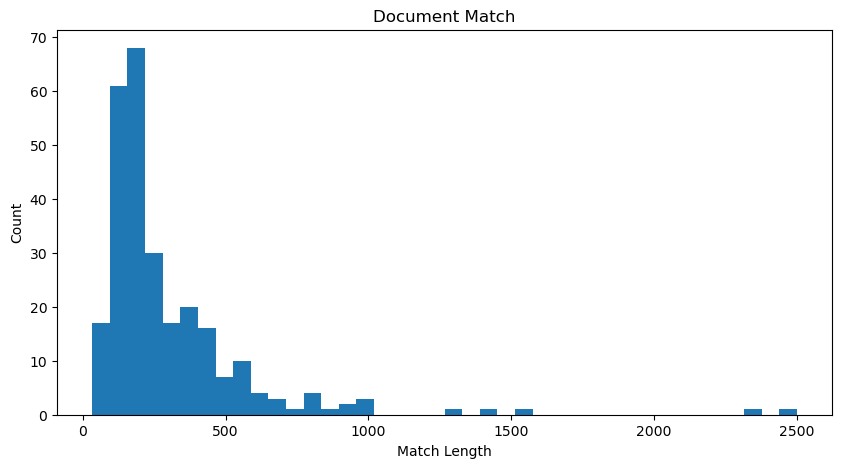

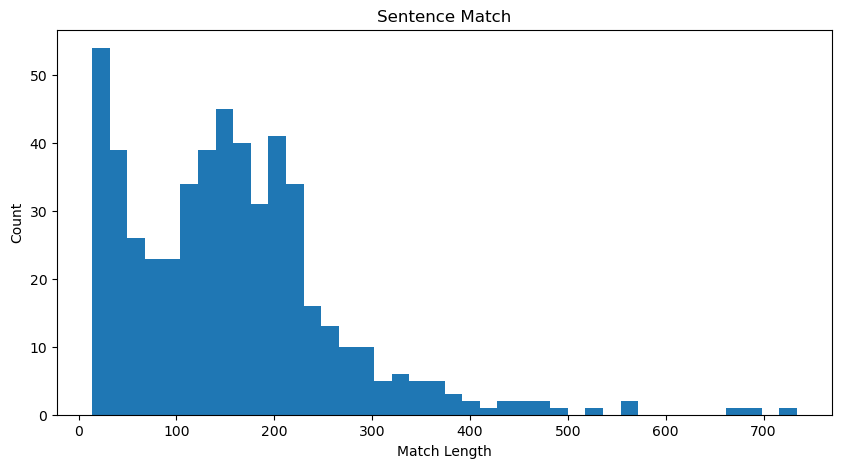

In [13]:
# check matching results
from matplotlib import pyplot as plt
noneCount = 0
docLengths = []
sentLengths = []
for i in resultsAll:
    if len(resultsAll[i]) == 0:
        noneCount += 1
        continue
    lenDoc = 0
    for e in resultsAll[i]:
        lenDoc += len(e[0])
        sentLengths.append(len(e[0]))
    docLengths.append(lenDoc)
print(f'Found {noneCount} documents missing matched text out of {len(docs)} documents.')
docLengths = sorted(docLengths, reverse=True)
sentLengths = sorted(sentLengths, reverse=True)
def drawHist(data, title=''):
    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=40)
    plt.xlabel('Match Length')
    plt.ylabel('Count')
    if len(title) > 0:
        plt.title(title)
    plt.show()
drawHist(docLengths, 'Document Match')
drawHist(sentLengths, 'Sentence Match')

In [14]:
import re
rule2_keywords = ["胡锦涛", "温家宝", "习近平", "李克强", "党中央", "国务院"]
rule2_regex = re.compile('|'.join(rule2_keywords))
def rule2(text):
    lines = text.split('\n')
    matches = []
    for line in lines:
        if len(line.strip()) > 0:
            lineMatch = rule2_regex.search(line)
            if lineMatch is not None:
                matches.append((line.strip(), lineMatch.group().strip()))
    return matches

In [15]:
# run rule 2 on all samples
resultsAll = {}
for i in range(len(docs)):
    with open(os.path.join(os.getcwd(), '..', 'sample', docs[i]), 'r', encoding='utf-8') as f:
        text = f.read()
        resultsLocal = rule2(text)
        resultsAll[i] = resultsLocal
noneCount = 0
for i in resultsAll:
    if len(resultsAll[i]) == 0:
        noneCount += 1
        continue
    lenDoc = 0
    for e in resultsAll[i]:
        lenDoc += len(e[0])
print(f'Found {noneCount}/{len(docs)} documents missing matched text.')

Found 590/859 documents missing matched text.


In [48]:
import re, cn2an
rule3_regex = re.compile(r"总\s*则|指导思想|基本原则")
def rule3rule4(text):
    keywordMatch = rule3_regex.search(text)
    if keywordMatch is None:
        return []
    # index of the keyword
    keywordIndex = keywordMatch.start()
    # move index to the start of the line
    while keywordIndex > 0:
        if text[keywordIndex-1] == '\n':
            break
        keywordIndex -= 1
    # trim text and start searching
    text = text[keywordIndex:]
    matches = []
    # iterate lines
    lines = text[keywordMatch.end()+1:].split('\n')
    for i in range(len(lines)):
        line = lines[i].strip()
        if len(line) == 0:
            continue
        temp = []
        temp += [line]
        number_pattern = re.compile(r'\d+')
        number_chinese_pattern = re.compile(r'(?:(?:[一二三四五六七八九]十)?[一二三四五六七八九]|十[一二三四五六七八九]?|二十|三十|四十|五十|六十|七十|八十|九十)')
        end_word = ''
        try:
            # search for number (numeric or Chinese character)
            numberMatch = re.search(number_pattern, line)
            if numberMatch is not None and int(numberMatch.group()) < 999:
                number = numberMatch.group()
                numberIndex = numberMatch.start()
                target_number = str(int(number) + 1)
                target_number = str(target_number)
                end_word = target_number + line[numberIndex + len(number)]
            elif number_chinese_pattern.search(line):
                numberMatch = number_chinese_pattern.search(line)
                number = numberMatch.group()
                numberIndex = numberMatch.start()
                number_int = cn2an.cn2an(number) + 1
                target_number = cn2an.an2cn(number_int)
                end_word = target_number + line[numberIndex + len(number)]
        except:
            pass
        # search for end word if any, otherwise get the next line
        if len(end_word) > 0:
            '''
            reach_end = True
            i += 1
            while i < len(paragraphs) and reach_end:
                if end_word in paragraphs[i]:
                    reach_end = False
                    break
                temp += [paragraphs[i]]
                i += 1
            if reach_end == False:
                # add list 
                for index, sentence in enumerate(temp):
                    if index == 0:
                        matched_paragraphs.append((sentence, re.search('|'.join(rule_3_keyword), sentence).group()))
                    else:
                        matched_paragraphs.append((sentence, "总则/指导思想/基本原则内容"))
            else:
                temp = [line]
                next_index = paragraphs.index(line) + 1
                if next_index < len(paragraphs):
                    temp += [paragraphs[next_index]]
                    for index, sentence in enumerate(temp):
                        if index == 0:
                            matched_paragraphs.append((sentence, re.search('|'.join(rule_3_keyword), sentence).group()))
                        else:
                            matched_paragraphs.append((sentence, "总则/指导思想/基本原则内容"))
                else:
                    matched_paragraphs.append((line.strip(), [keyword for keyword in rule_3_keyword if keyword in line][0]))
                i = next_index
            ''' # refactor as below 
            print('debug 1', end_word)
            targetMatch = re.search(end_word, text)
            if targetMatch is not None:
                print('debug 2')
                targetIndex = targetMatch.start()
                while targetIndex > 0:
                    if text[targetIndex-1] == '\n':
                        break
                    targetIndex -= 1
                matches.append((text[:targetIndex], "总则/指导思想/基本原则内容"))
                return matches
            else:
                print('debug 3')
                break
        else:
            break
            '''
            temp = [line]
            next_index = paragraphs.index(line) + 1
            if next_index < len(paragraphs):
                temp += [paragraphs[next_index]]
                for index, sentence in enumerate(temp):
                    if index == 0:
                        matched_paragraphs.append((sentence, re.search('|'.join(rule_3_keyword), sentence).group()))
                    else:
                        matched_paragraphs.append((sentence, "总则/指导思想/基本原则内容"))
            else:
                matched_paragraphs.append((line.strip(), [keyword for keyword in rule_3_keyword if keyword in line][0]))
            ''' # refactor as below
    # fallback case when: 1) invalid number, 2) no end word found, or 3) end word found but not matched
    if i < len(lines)-1:
        matches.append((lines[i], "总则/指导思想/基本原则内容"))
        while i < len(lines):
            i += 1
            if len(lines[i].strip()) > 0:
                matches.append((lines[i], "总则/指导思想/基本原则内容"))
                return matches
    return []

In [28]:
# run rule 3&4 on all samples
resultsAll = {}
resultsSentence = []
for i in range(len(docs)):
    with open(os.path.join(os.getcwd(), '..', 'sample', docs[i]), 'r', encoding='utf-8') as f:
        text = f.read()
        resultsLocal = rule3rule4(text)
        resultsAll[i] = resultsLocal
noneCount = 0
for i in resultsAll:
    if len(resultsAll[i]) == 0:
        noneCount += 1
        continue
    for e in resultsAll[i]:
        resultsSentence.append(e[0])
print(f'Found {noneCount}/{len(docs)} documents missing matched text.')

Found 661/859 documents missing matched text.


In [44]:
import random
resultsSentence[random.randrange(0, len(resultsSentence))]

'\u3000第一章\u3000总则\n\u3000\u3000第一条\u3000为深入贯彻落实习近平总书记关于城市管理的重要指示批示精神，坚持以人民为中心的发展思想，推动建设“创新发展、开放包容、生态宜居、民主法治、文明幸福”的现代化天津，全面加强天津城市管理工作，增强城市管理考核工作的针对性和有效性，增强“以奖代补”资金使用效能，依据《天津市文明行为促进条例》、《天津市城市管理规定》及有关法律、法规的规定，制定本办法。\n\u3000\u3000第二条\u3000本办法适用于对各区人民政府、市级城市管理相关职能部门开展城市管理考核工作。\n\u3000\u3000第三条\u3000城市管理考核紧紧围绕建设“五个现代化天津”和全国最整洁城市的目标，遵循公开、公平、公正的原则，确保每寸土地有人管、每件设施都管好、每个细节管到位，不断提高城市管理精细化、规范化、科学化水平，让城市生活更方便、更舒心、更美好。\n\n'

In [49]:
textTest = '\u3000第一章\u3000总则\n\u3000\u3000第一条\u3000根据《中华人民共和国预算法》及其实施条例、《国务院关于进一步深化预算管理制度改革的意见》（国发〔2021〕5号）以及《甘肃省预算审批监督条例》、《中共甘肃省委 甘肃省人民政府关于全面实施预算绩效管理的实施意见》（甘发〔2018〕32号）、《甘肃省人民政府关于进一步深化预算管理制度改革的实施意见》（甘政发〔2021〕55号）等有关规定，结合省级预算编制情况与部门预算管理的具体要求，制定本规程。\n\u3000\u3000第二条\u3000本规程所称预算编制是指与省级财政直接发生缴拨款关系的国家机关、军队武警、政党组织、事业单位（含企业化管理的事业单位）、社会团体和其他单位（含企业），组织、拟定、确定年度预算收支计划的过程。预算草案是指省级政府、各部门、各单位编制的未经法定程序审查和批准的预算。\n\u3000\u3000第三条\u3000预算编制坚持党的全面领导，坚持依法理财，坚持政策引领，坚持底线思维，量入为出、量力而行、统筹兼顾、保障重点。\n\u3000\u3000第四条\u3000预算编制以零基预算为基本方法，同步编制中期财政规划和部门三年支出规划，按“二上二下”的程序，利用信息网络手段组织进行。预算规模结合财力状况、轻重缓急、实际需求、绩效情况等，综合平衡统筹安排。\n\u3000\u3000第五条\u3000政府的全部收入和支出都纳入政府预算，包括一般公共预算、政府性基金预算、国有资本经营预算和社会保险基金预算。\n\n\u3000\u3000部门的所有收入和支出全部纳入部门预算统一管理。各部门预算由本部门及其所属各单位预算组成。\n\n'
rule3rule4(textTest)

debug 1 二条
debug 2


[('\u3000第一章\u3000总则\n\u3000\u3000第一条\u3000根据《中华人民共和国预算法》及其实施条例、《国务院关于进一步深化预算管理制度改革的意见》（国发〔2021〕5号）以及《甘肃省预算审批监督条例》、《中共甘肃省委 甘肃省人民政府关于全面实施预算绩效管理的实施意见》（甘发〔2018〕32号）、《甘肃省人民政府关于进一步深化预算管理制度改革的实施意见》（甘政发〔2021〕55号）等有关规定，结合省级预算编制情况与部门预算管理的具体要求，制定本规程。\n',
  '总则/指导思想/基本原则内容')]

In [52]:
def rule5(text):
    lines = text.split('\n')
    matches = []
    for line in lines:
        if line.startswith('\u3000\u3000') and len(line.strip()) > 5 and '法宝引证码' not in line:
            matches.append((line.strip(), "默认规则"))
    return matches

In [53]:
# run rule 5 on all samples
resultsAll = {}
resultsSentence = []
for i in range(len(docs)):
    with open(os.path.join(os.getcwd(), '..', 'sample', docs[i]), 'r', encoding='utf-8') as f:
        text = f.read()
        resultsLocal = rule5(text)
        resultsAll[i] = resultsLocal
noneCount = 0
for i in resultsAll:
    if len(resultsAll[i]) == 0:
        noneCount += 1
        continue
    for e in resultsAll[i]:
        resultsSentence.append(e[0])
print(f'Found {noneCount}/{len(docs)} documents missing matched text.')

Found 36/859 documents missing matched text.
